# Google Ajou AI Capstone Base Notebook

팀원이 Colab 또는 로컬에서 개인 폴더의 코드를 쉽게 실행하기 위한 최소 스켈레톤입니다.

- `USER_FOLDER`: repo 안의 개인 폴더명
- `RUN_FILE`: 개인 폴더 기준으로 실행할 Python 파일. 예: `test/test.py`
- 개인 폴더에 `requirements.txt` 또는 `requirement.txt`가 있으면 자동 설치합니다.
- 지정한 파일을 일반 Python script처럼 그대로 실행합니다.
- 실행 시 작업 디렉터리는 실행 파일이 있는 폴더로 이동합니다.
- 공통 경로가 필요하면 실행 파일 안에서 `PROJECT_ROOT`, `DATA_ROOT`, `USER_ROOT` 변수를 바로 사용할 수 있습니다.


## 셀 1. 기본 환경 준비

Colab이면 Google Drive를 마운트하고, `/content/Google-Ajou-AICapstone`의 기존 checkout을 제거한 뒤 `origin/main`을 새로 clone합니다. 따라서 Cell 1을 다시 실행하면 최신 push가 반영됩니다.


In [ ]:
# Cell 1 - Environment setup
import os
import runpy
import shutil
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/Pig30nidaE/Google-Ajou-AICapstone.git"
REPO_DIR_NAME = "Google-Ajou-AICapstone"


def in_colab():
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False


IN_COLAB = in_colab()

if IN_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive")


def find_project_root():
    cwd = Path.cwd().resolve()
    for path in [cwd, *cwd.parents]:
        if (path / "base.ipynb").exists() or (path / "Data").exists():
            return path
    return None


if IN_COLAB:
    content_root = Path("/content").resolve()
    clone_path = content_root / REPO_DIR_NAME
    if clone_path.parent != content_root or clone_path.name != REPO_DIR_NAME:
        raise RuntimeError(f"Unsafe clone path: {clone_path}")
    os.chdir(content_root)
    if clone_path.exists():
        stale_modules = []
        for module_name, module in list(sys.modules.items()):
            module_file = getattr(module, "__file__", None)
            if not module_file:
                continue
            try:
                Path(module_file).resolve().relative_to(clone_path)
            except (OSError, ValueError):
                continue
            stale_modules.append(module_name)
        for module_name in stale_modules:
            sys.modules.pop(module_name, None)
        print(f"Cleared stale modules: {len(stale_modules)}")
        print(f"Removing stale checkout: {clone_path}")
        shutil.rmtree(clone_path)
    subprocess.run(
        [
            "git", "clone", "--depth", "1", "--branch", "main",
            "--single-branch", REPO_URL, str(clone_path),
        ],
        check=True,
    )
    PROJECT_ROOT = clone_path
    checkout_commit = subprocess.run(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "--short", "HEAD"],
        check=True, capture_output=True, text=True,
    ).stdout.strip()
else:
    PROJECT_ROOT = find_project_root()

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd().resolve()

os.chdir(PROJECT_ROOT)

if IN_COLAB:
    DATA_ROOT = Path("/content/drive/Shareddrives/GoogleAI_contest/Data")
else:
    DATA_ROOT = PROJECT_ROOT / "Data"

if not DATA_ROOT.exists() and (PROJECT_ROOT / "Data").exists():
    DATA_ROOT = PROJECT_ROOT / "Data"

print(f"IN_COLAB     : {IN_COLAB}")
print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_ROOT    : {DATA_ROOT}")
if IN_COLAB:
    print(f"CHECKOUT     : {checkout_commit}")


## 셀 2. 사용자 입력

여기만 수정하면 됩니다. `RUN_FILE`은 `USER_FOLDER` 기준 상대경로로 쓰는 것을 권장합니다.


In [ ]:
# Cell 2 - User inputs
USER_FOLDER = "SangHyo"
RUN_FILE = "test/test.py"


## 셀 3. 경로 확인

개인 폴더와 실행할 파일 경로를 확인합니다. 파일이 없으면 여기에서 바로 에러가 납니다.


In [ ]:
# Cell 3 - Resolve paths
USER_ROOT = (PROJECT_ROOT / USER_FOLDER).resolve()
RUN_PATH = Path(RUN_FILE).expanduser()

if not RUN_PATH.is_absolute():
    RUN_PATH = USER_ROOT / RUN_PATH

RUN_PATH = RUN_PATH.resolve()

if not RUN_PATH.exists() and RUN_PATH.suffix == "":
    py_path = RUN_PATH.with_suffix(".py")
    if py_path.exists():
        RUN_PATH = py_path

if not USER_ROOT.exists():
    raise FileNotFoundError(f"User folder does not exist: {USER_ROOT}")

if not RUN_PATH.exists():
    raise FileNotFoundError(
        f"Run file does not exist: {RUN_PATH}\n"
        "Check RUN_FILE. Example: RUN_FILE = 'test/test.py'"
    )

print(f"USER_ROOT : {USER_ROOT}")
print(f"RUN_PATH  : {RUN_PATH}")


## 셀 4. 개인 requirements 설치

개인 폴더에 `requirements.txt` 또는 `requirement.txt`가 있으면 설치하고, 없으면 스킵합니다.


In [ ]:
# Cell 4 - Install user requirements if present
requirements_files = [
    USER_ROOT / "requirements.txt",
    USER_ROOT / "requirement.txt",
]

requirements_files = [path for path in requirements_files if path.exists()]

if requirements_files:
    for requirements_file in requirements_files:
        print(f"Installing: {requirements_file}")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-r", str(requirements_file)],
            check=True,
        )
else:
    print("No requirements file found. Skip install.")


## 셀 5. 개인 코드 실행

지정한 Python 파일을 그대로 실행합니다. 개인 코드마다 실행 방식이 달라도, 이 셀은 파일을 실행하는 역할만 합니다.

실행 중에는 15초마다 경과 시간(하트비트)이 출력되어 진행 상태를 확인할 수 있고, 실제 단계별 로그는 실행 코드가 출력하는 내용이 실시간으로 그대로 표시됩니다.

Run file    : /content/Google-Ajou-AICapstone/SangHyo/Reproduction/reproduction_lee_lee_2025_vae/repro_v4.py
Working dir : /content/Google-Ajou-AICapstone/SangHyo/Reproduction/reproduction_lee_lee_2025_vae
device: cuda | torch 2.11.0+cu128 | QUICK_TEST=False
DATA_DIR : /content/drive/MyDrive/Data
OUT_DIR  : /content/drive/MyDrive/reproduction_lee_lee_2025_vae_notebook/20260813_104629_v4
클래스  기록(실측)  기록(논문 표3)  피험자(실측)  피험자(논문 표3)
 CN    7737       7737      111         111
MCI    3661       3661       51          51
Dem     785        785       12          12
→ 논문 표 3과 일치 ✅ (결측 0)

실험 A — 논문 절차 재구성 (행 8:1:1, 전처리 전체 적합=의도된 누수)
이상치 제거 후 {'CN': 7075, 'MCI': 3374, 'Dem': 515} | 논문 §5.1 {'CN':7075,'MCI':3374,'Dem':515} (IF random_state=110)
train 8771 / valid 1096 / test 1097 (논문 표 5: 8,771/1,098/1,095) | test Dem 51행 (논문 51)
train∩test 피험자 중복 171명 — 행 분할의 구조적 누수 (의도된 재현)
VAE 레시피 paper: latent 500, 300 epoch
  ⏳ 실행 중... 00:15 경과
  VAE ep 60/300 recon(변수당)=0.4685 β=1.00
  VAE ep 120/300 reco

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  A[42] tabnet    none | test macro-F1 0.8240 Dem F1 0.7835 | valid Dem F1 0.7788
  ⏳ 실행 중... 07:15 경과
  ⏳ 실행 중... 07:30 경과
  ⏳ 실행 중... 07:45 경과
  ⏳ 실행 중... 08:00 경과
  ⏳ 실행 중... 08:15 경과
  ⏳ 실행 중... 08:30 경과
  ⏳ 실행 중... 08:45 경과
  ⏳ 실행 중... 09:00 경과
  ⏳ 실행 중... 09:15 경과
  ⏳ 실행 중... 09:30 경과
  ⏳ 실행 중... 09:45 경과
  ⏳ 실행 중... 10:00 경과
  ⏳ 실행 중... 10:15 경과
  ⏳ 실행 중... 10:30 경과
  ⏳ 실행 중... 10:45 경과
  ⏳ 실행 중... 11:00 경과
  ⏳ 실행 중... 11:15 경과
  ⏳ 실행 중... 11:30 경과
  ⏳ 실행 중... 11:45 경과
  ⏳ 실행 중... 12:00 경과
  ⏳ 실행 중... 12:15 경과
  ⏳ 실행 중... 12:30 경과
  ⏳ 실행 중... 12:45 경과
  ⏳ 실행 중... 13:00 경과
  ⏳ 실행 중... 13:15 경과
  ⏳ 실행 중... 13:30 경과
  ⏳ 실행 중... 13:45 경과
  ⏳ 실행 중... 14:00 경과
  ⏳ 실행 중... 14:15 경과
  ⏳ 실행 중... 14:30 경과
Stop training because you reached max_epochs = 200 with best_epoch = 178 and best_val_0_balanced_accuracy = 0.84887


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  A[42] tabnet    vae  | test macro-F1 0.8055 Dem F1 0.7379 | valid Dem F1 0.7719
  ⏳ 실행 중... 14:45 경과
  A[42] wide_deep none | test macro-F1 0.8389 Dem F1 0.7917 | valid Dem F1 0.7600
  ⏳ 실행 중... 15:00 경과
  ⏳ 실행 중... 15:15 경과
  A[42] wide_deep vae  | test macro-F1 0.8312 Dem F1 0.7660 | valid Dem F1 0.7619
[seed 43] VAE recon 0.2073 | posterior μ-std 0.351
  합성 진단: σ비 0.319 (paper 레시피의 예상된 붕괴) | 평균 이동 0.071σ
  A[43] xgboost   none | test macro-F1 0.8018 Dem F1 0.7907 | valid Dem F1 0.6905
  ⏳ 실행 중... 15:30 경과
  A[43] xgboost   vae  | test macro-F1 0.7868 Dem F1 0.7356 | valid Dem F1 0.7143
  ⏳ 실행 중... 15:45 경과
  ⏳ 실행 중... 16:00 경과
  ⏳ 실행 중... 16:15 경과
  A[43] dnn       none | test macro-F1 0.8595 Dem F1 0.8454 | valid Dem F1 0.8119
  ⏳ 실행 중... 16:30 경과
  ⏳ 실행 중... 16:45 경과
  ⏳ 실행 중... 17:00 경과
  ⏳ 실행 중... 17:15 경과
  ⏳ 실행 중... 17:30 경과
  A[43] dnn       vae  | test macro-F1 0.8772 Dem F1 0.8602 | valid Dem F1 0.8654
  ⏳ 실행 중... 17:45 경과
  ⏳ 실행 중... 18:00 경과
  ⏳ 실행 중... 18:15 경과
  ⏳ 실행 

...

  ⏳ 실행 중... 137:45 경과
  ⏳ 실행 중... 138:00 경과

Early stopping occurred at epoch 52 with best_epoch = 2 and best_val_0_balanced_accuracy = 0.40851


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  ⏳ 실행 중... 138:15 경과
  C outer 2 inner 2 완료 (41.6분 경과)
  C outer 2 선택: tabnet + vae_r3 (inner macro-F1 0.3386)
  ⏳ 실행 중... 138:30 경과
  ⏳ 실행 중... 138:45 경과
  ⏳ 실행 중... 139:00 경과
  ⏳ 실행 중... 139:15 경과
  ⏳ 실행 중... 139:30 경과
  ⏳ 실행 중... 139:45 경과

Early stopping occurred at epoch 62 with best_epoch = 12 and best_val_0_balanced_accuracy = 0.39288


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  C outer 2 | subj macro-F1 0.3272 Dem 0/4

[실험 C pooled — 174명] macro-F1 0.4301 (95% CI [0.321, 0.53]), Dem 3/12
실험 C 완료 — 43.1분


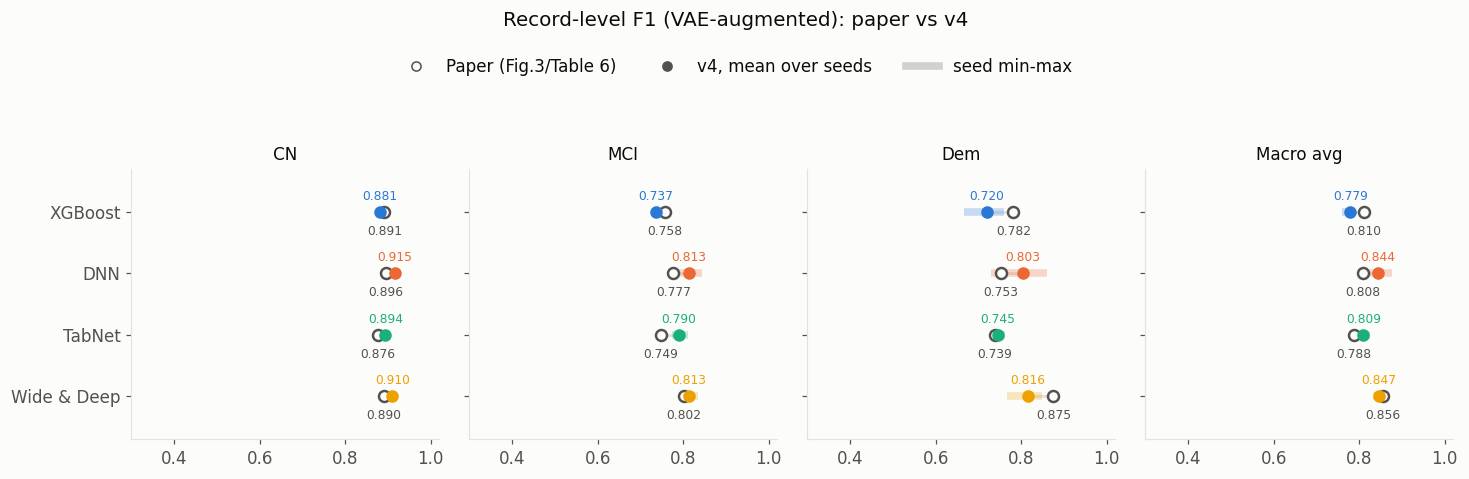

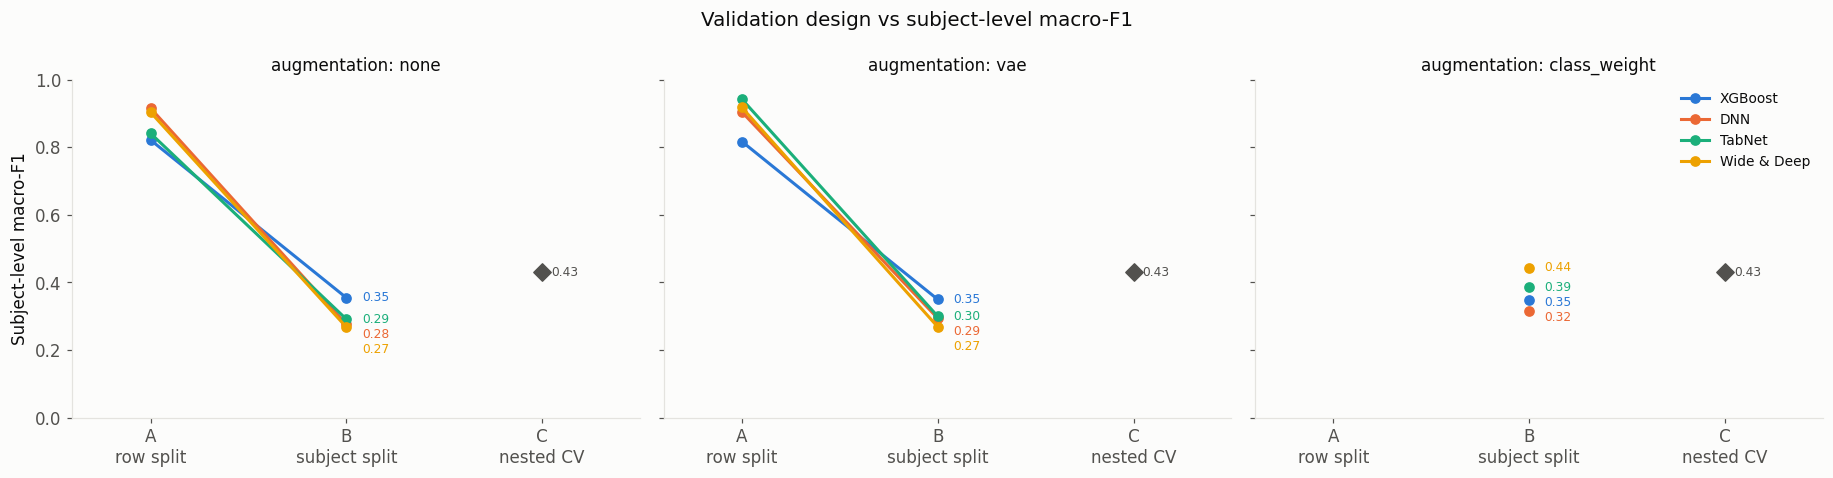

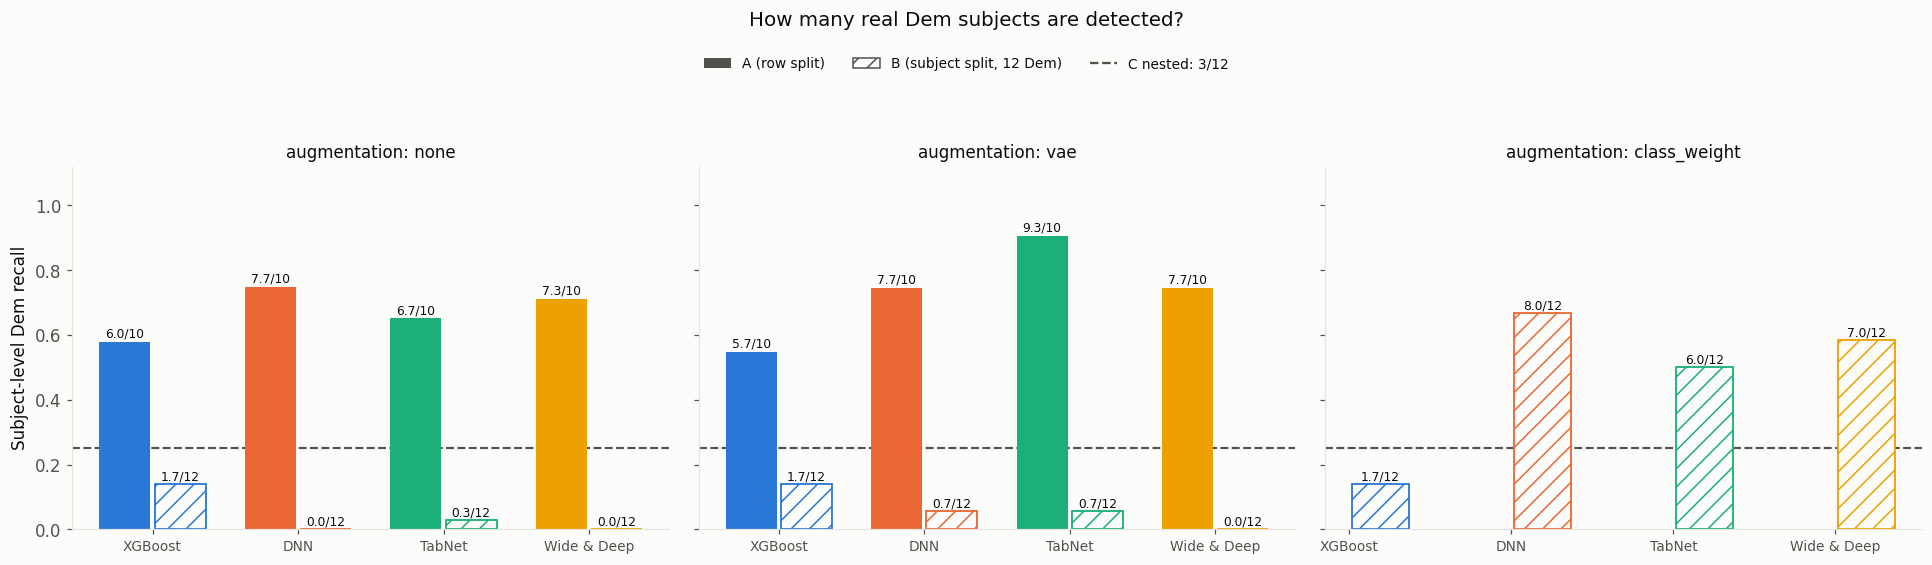

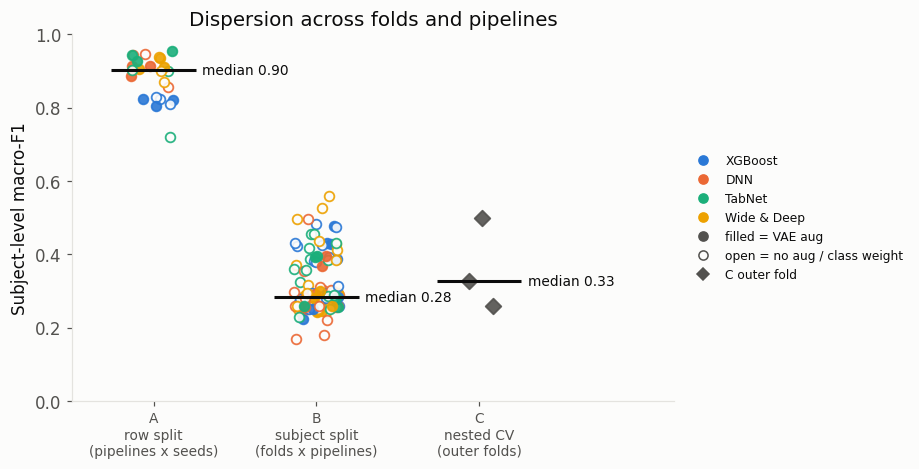


산출물 저장 → /content/drive/MyDrive/reproduction_lee_lee_2025_vae_notebook/20260813_104629_v4
   A_metrics.csv
   A_metrics_seed_mean.csv
   B_fold_metrics.csv
   B_pooled_by_seed.json
   B_pooled_subject_metrics.json
   C_outer_metrics.csv
   C_pooled_subject_metrics.json
   C_selection_log.csv
   config.json
   fig1_paper_vs_A.png
   fig2_designs.png
   fig3_dem_detection.png
   fig4_dispersion.png
전체 완료 — 139.9분

해석 주의: Dem은 독립 피험자 12명이다. 합성행은 새 피험자가 아니며,
피험자 단위 지표의 분모는 항상 실제 피험자 수다. QUICK_TEST 결과는 인용 금지.
✅ Done. (총 139:56 소요)


In [17]:
# Cell 5 - Run selected file (with a live progress heartbeat)
import threading
import time

previous_cwd = Path.cwd()
os.chdir(RUN_PATH.parent)

# Stream child prints immediately (Colab can buffer stdout otherwise).
try:
    sys.stdout.reconfigure(line_buffering=True)
except Exception:
    pass

print(f"Run file    : {RUN_PATH}")
print(f"Working dir : {Path.cwd()}")

# A background heartbeat prints elapsed time every 15s so that long silent steps
# (e.g. nested cross-validation) still show visible progress in the cell output.
# It only prints elapsed time; per-step detail comes from whatever the run file
# itself prints, which streams here live.
_run_done = threading.Event()
_run_start = time.monotonic()


def _progress_heartbeat(interval=15.0):
    while not _run_done.wait(interval):
        elapsed = int(time.monotonic() - _run_start)
        print(f"  ⏳ 실행 중... {elapsed // 60:02d}:{elapsed % 60:02d} 경과", flush=True)


_heartbeat_thread = threading.Thread(target=_progress_heartbeat, daemon=True)
_heartbeat_thread.start()

try:
    result = runpy.run_path(
        str(RUN_PATH),
        init_globals={
            "PROJECT_ROOT": PROJECT_ROOT,
            "DATA_ROOT": DATA_ROOT,
            "USER_ROOT": USER_ROOT,
            "RUN_PATH": RUN_PATH,
        },
        run_name="__main__",
    )
finally:
    _run_done.set()
    _heartbeat_thread.join(timeout=1.0)
    os.chdir(previous_cwd)

_total = int(time.monotonic() - _run_start)
print(f"✅ Done. (총 {_total // 60:02d}:{_total % 60:02d} 소요)")